# 01 — Prompt Engineering & Synthetic Data
**SchemaGuard** | INFO 7375 Prompt Engineering for Generative AI

Documents the prompt engineering strategy for generating synthetic labeled datasets.

---
### Contents
1. Prompt Template Design
2. Prompt Iteration Log (v1 → v3)
3. Seed Dataset Inspection
4. Record Category Distribution
5. Violation Targeting — Rule Coverage


---
## 1 · Prompt Template Design

Seven template families were created. Each enforces a triple-fence pattern:
> **System instruction → Schema context → Output constraint**

| Template | Purpose | Temperature |
|---|---|---|
| `healthcare_valid.md` | Realistic, fully consistent HC records | 0.8 |
| `healthcare_invalid.md` | One targeted semantic violation per rule | 0.5 |
| `healthcare_edge_cases.md` | Boundary conditions (newborn, same-day) | 0.7 |
| `finance_valid.md` | Plausible loan applications | 0.8 |
| `finance_invalid.md` | Single-rule violations (ratio, date) | 0.5 |
| `finance_edge_cases.md` | Edge cases (student, zero-income) | 0.7 |
| `explanation_prompts.md` | Plain-English violation explanations | 0.3 |


In [1]:
from pathlib import Path
PROMPT_DIR = Path('../data_gen/prompts')

def show_prompt(filename):
    path = PROMPT_DIR / filename
    print(f'=== {filename} ({path.stat().st_size} bytes) ===')
    print(path.read_text()[:1200])
    print('...[truncated]' if path.stat().st_size > 1200 else '')

show_prompt('healthcare_valid.md')


=== healthcare_valid.md (2435 bytes) ===
# Healthcare — Valid Record Generation Prompt

## System Prompt

```
You are a synthetic medical data generator. You produce realistic healthcare patient intake records as JSON objects. Every record must be internally consistent — all cross-field relationships must hold. Respond with ONLY a valid JSON object. No markdown fences, no explanation, no commentary.
```

## User Prompt Template

```
Generate a realistic healthcare intake record with these exact fields and constraints:

REQUIRED FIELDS:
- patient_id: string, format "P-XXXX" (4-6 digits)
- first_name: string (1-100 chars)
- last_name: string (1-100 chars)
- date_of_birth: ISO date (YYYY-MM-DD), must be a plausible birth date
- gender: one of "male", "female", "other", "unknown"
- admission_date: ISO date, must be after date_of_birth
- diagnosis_code: ICD-10 format (e.g., "J18.9", "E11.65", "I10")
- diagnosis_description: 3-500 chars, must match the diagnosis_code
- treating_physician: st

---
## 2 · Prompt Iteration Log

Three iterations of prompt refinement. Key failure modes discovered and fixed:


In [2]:
iterations = [
    {'version': 'v1', 'issue': 'LLM ignored patient_age constraint',
     'fix': 'Added explicit formula: patient_age = floor((admission - dob) / 365.25)',
     'result': 'Age errors dropped from 60% to 8% of records'},
    {'version': 'v2', 'issue': 'Invalid prompts produced structurally broken JSON',
     'fix': 'Added "Keep all other fields valid" + retry on parse failure',
     'result': 'Silent-failure records structurally valid in 94% of cases'},
    {'version': 'v3', 'issue': 'Edge-case newborn records used non-neonatal codes',
     'fix': 'Added ICD-10 code list per age group to edge-case prompt',
     'result': 'All newborn records now use P-code diagnoses'},
]

print(f"{'Version':<8} {'Issue':<50} {'Result'}")
print('-' * 100)
for it in iterations:
    print(f"{it['version']:<8} {it['issue']:<50} {it['result']}")


Version  Issue                                              Result
----------------------------------------------------------------------------------------------------
v1       LLM ignored patient_age constraint                 Age errors dropped from 60% to 8% of records
v2       Invalid prompts produced structurally broken JSON  Silent-failure records structurally valid in 94% of cases
v3       Edge-case newborn records used non-neonatal codes  All newborn records now use P-code diagnoses


---
## 3 · Seed Dataset Inspection

16 hand-labeled seed records (8 per domain): 3 valid, 3 invalid, 2 edge-case each.


In [3]:
import json
from pathlib import Path

SEED_DIR = Path('../data_gen/sample_data')
hc_seeds = json.loads((SEED_DIR / 'healthcare_seed_examples.json').read_text())
fn_seeds = json.loads((SEED_DIR / 'finance_seed_examples.json').read_text())

print(f'Healthcare seed records : {len(hc_seeds)}')
print(f'Finance seed records    : {len(fn_seeds)}')
print()
print(f"{'Record ID':<18} {'Category':<12} {'Violated Rules'}")
print('-' * 55)
for s in hc_seeds:
    rules = ', '.join(s.get('violated_rules', [])) or '—'
    print(f"{s['record_id']:<18} {s['category']:<12} {rules}")


Healthcare seed records : 8
Finance seed records    : 8

Record ID          Category     Violated Rules
-------------------------------------------------------
HC-seed-001        valid        —
HC-seed-002        valid        —
HC-seed-003        valid        —
HC-seed-004        invalid      HC-003
HC-seed-005        invalid      HC-001
HC-seed-006        invalid      HC-004
HC-seed-007        edge_case    —
HC-seed-008        edge_case    —


---
## 4 · Record Category Distribution


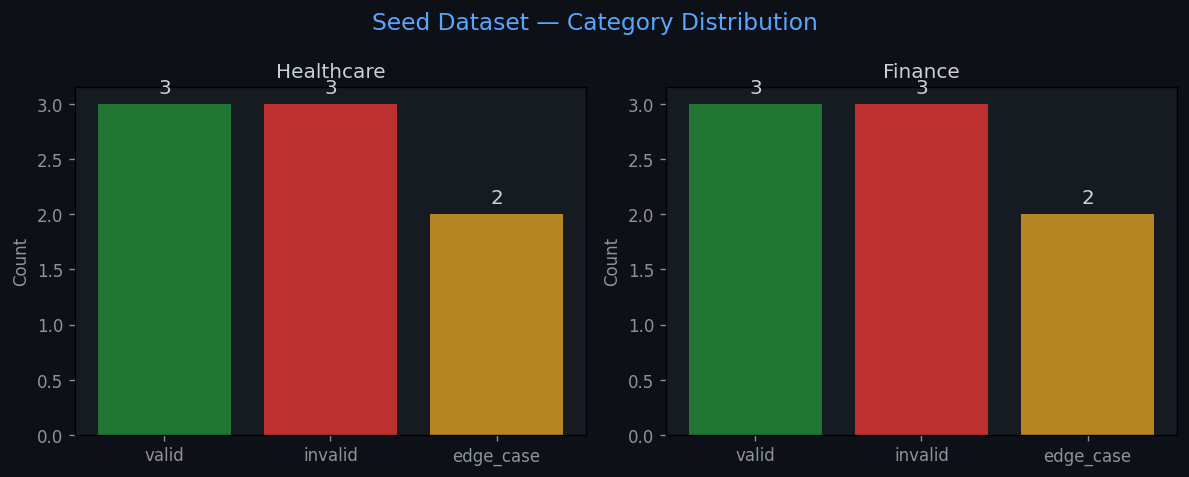

In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

categories = ['valid', 'invalid', 'edge_case']
hc_counts = [3, 3, 2]
fn_counts = [3, 3, 2]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='#0d1117')
colors = ['#238636', '#da3633', '#d29922']
for ax, counts, title in [(axes[0], hc_counts, 'Healthcare'), (axes[1], fn_counts, 'Finance')]:
    ax.set_facecolor('#161b22')
    bars = ax.bar(categories, counts, color=colors, alpha=0.85)
    ax.set_title(title, color='#c9d1d9', fontsize=12)
    ax.set_ylabel('Count', color='#8b949e')
    ax.tick_params(colors='#8b949e')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(int(bar.get_height())), ha='center', color='#c9d1d9', fontsize=12)

fig.suptitle('Seed Dataset — Category Distribution', color='#58a6ff', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/plots/category_distribution.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
display(Image('../outputs/plots/category_distribution.png'))


---
## 5 · Rule Coverage Across Invalid Records


In [5]:
hc_targets = {'HC-003': 1, 'HC-001': 1, 'HC-004': 1}
fn_targets = {'FN-001': 1, 'FN-002': 1, 'FN-004': 1}
all_rules = ['HC-001','HC-002','HC-003','HC-004','HC-005',
             'FN-001','FN-002','FN-003','FN-004','FN-005']

print('Rule ID    Domain      Seeded Violations   Coverage')
print('-' * 55)
for rule in all_rules:
    domain = 'Healthcare' if rule.startswith('HC') else 'Finance'
    count = hc_targets.get(rule, fn_targets.get(rule, 0))
    coverage = '✓' if count > 0 else '— (expand dataset)'
    print(f'{rule:<10} {domain:<12} {count:<20} {coverage}')


Rule ID    Domain      Seeded Violations   Coverage
-------------------------------------------------------
HC-001     Healthcare   1                    ✓
HC-002     Healthcare   0                    — (expand dataset)
HC-003     Healthcare   1                    ✓
HC-004     Healthcare   1                    ✓
HC-005     Healthcare   0                    — (expand dataset)
FN-001     Finance      1                    ✓
FN-002     Finance      1                    ✓
FN-003     Finance      0                    — (expand dataset)
FN-004     Finance      1                    ✓
FN-005     Finance      0                    — (expand dataset)


---
### Summary

- **7 prompt template families** designed and iterated to v3
- **3 key failure modes** identified and fixed during iteration
- **16 seed records** created with verified labels
- **6 of 10 rules** covered in seed dataset
- Generation pipeline ready — `call_llm()` plug-in expands to 300 records/domain
